This minimal notebook runs **normative modeling** of static **functional connectivity** data as a function of **age**. It runs multiple models and selects the best one according to a predictive accuracy criterion.

Non-linear generalized additive models of location scale and shape (gamlss) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of functional connectivity. The best model is selected and plotted with its quantiles.

In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their FC and FCD (FC dynamics, time-varying) matrices computed from BOLD FMRI recordings.

In [2]:
cwd = os.getcwd()

In [3]:
fc_df = pd.read_json('FUNC_df.json')

In [4]:
fc_df.isna().sum()

SubjectID    0
Age          1
FC           0
FCD          0
dtype: int64

In [5]:
fc_df = fc_df.dropna()
fc_df['FC'] = fc_df['FC'].apply(np.array)
fc_df['FCD'] = fc_df['FCD'].apply(lambda x : np.array(x, dtype='float64'))

In [6]:
fc_df['Mean_FC'] = fc_df['FC'].apply(np.mean)
fc_df['Var_FC'] = fc_df['FC'].apply(np.var)
fc_df['Mean_triuFC'] = fc_df['FC'].apply(lambda x: np.mean(x[np.triu_indices_from(x, k=1)]))
fc_df['Var_triuFC'] = fc_df['FC'].apply(lambda x: np.var(x[np.triu_indices_from(x, k=1)]))

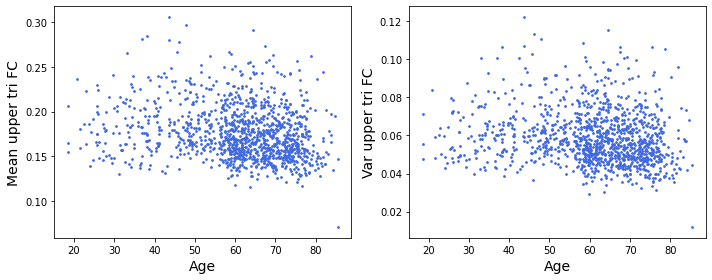

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True)
ax[0].scatter(fc_df['Age'], fc_df['Mean_triuFC'], s=3, color='royalblue') ; ax[0].set(ylabel='Mean upper tri FC')
ax[1].scatter(fc_df['Age'], fc_df['Var_triuFC'], s=3, color='royalblue') ; ax[1].set(ylabel='Var upper tri FC')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.tight_layout()
plt.show()

In [ ]:
x_str = 'Age' ; y_str = 'Mean_triuFC'

In [8]:
models_dict, compare = run_all_and_compare(fc_df, x_str, y_str, reg_type='gamlss')

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_triuFC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 89 seconds.
There were 191 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_triuFC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:275: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1038: RuntimeWarning: overflow encountered in divide
  b_ary /= prior_bs * ary[int(n / 4 + 0.5) - 1]
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1042: RuntimeWarning: invalid value encountered in divide
  len_scale = n * (np.log(-(b_ary / k_ary)) - k_ary - 1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1058: RuntimeWarning: invalid value encountered in scalar divide
  sigma = -k_post / 

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

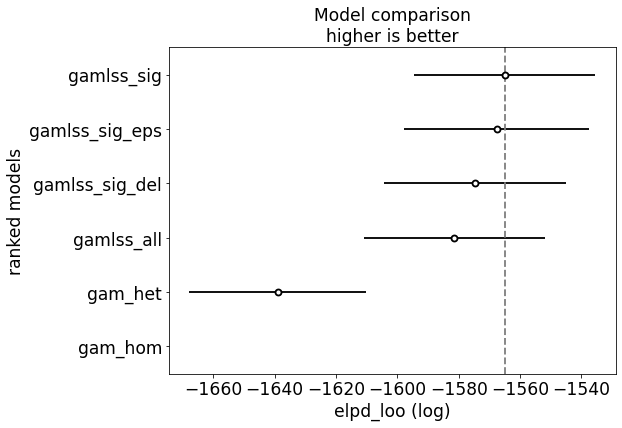

In [10]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 

Sampling: [y_like]


Output()

/tmp/ipykernel_19117/850752960.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


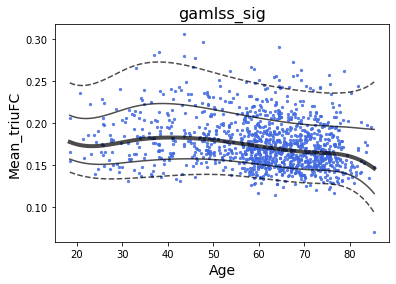

In [22]:
name = get_best(compare)
with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
    nm = pickle.load(file)
inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
fig, ax = plt.subplots(1)
ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler, n_qs=2, ax=ax)
ax.set_title(name)
fig.show()

In [23]:
x_str = 'Age' ; y_str = 'Var_triuFC'

In [24]:
models_dict, compare = run_all_and_compare(fc_df, x_str, y_str, reg_type='gamlss')

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Var_triuFC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 86 seconds.
There were 50 divergences after tuning. Increase `target_accept` or reparameterize.


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Var_triuFC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:275: RuntimeWarning: divide by zero encountered in log
  fun = None
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO p

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

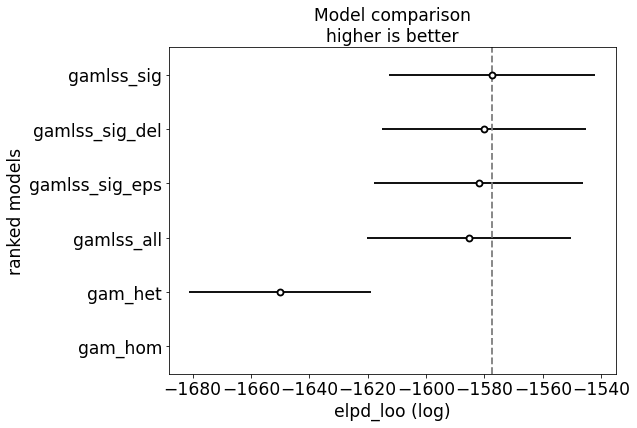

In [25]:
fig, ax = plt.subplots(1, figsize=(8, 6))
az.plot_compare(compare, ax=ax) 

Sampling: [y_like]


Output()

/tmp/ipykernel_19117/850752960.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


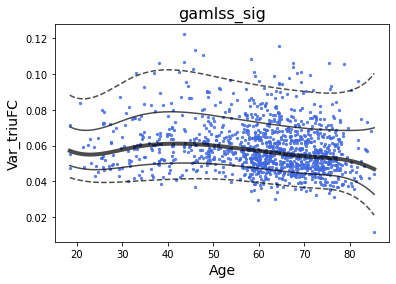

In [26]:
name = get_best(compare)
with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
    nm = pickle.load(file)
inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')
fig, ax = plt.subplots(1)
ax = plot_quantiles(nm, fc_df, x_str, y_str, inscaler, outscaler, n_qs=2, ax=ax)
ax.set_title(name)
fig.show()